processing non_cmorised data for heat transport

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import pandas as pd


In [4]:
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [5]:
os.cpu_count()

56

In [6]:
import cmocean
from scipy import stats

In [7]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [8]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [9]:
from matplotlib.colors import BoundaryNorm as BM
# from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [10]:
def plot_background(ax, draw_labels=False):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax



def add_qk_bbox(ax, qk, q, patch_zorder):
    # --- Add a box around both arrow and label ---
    # Choose size & position in Axes fraction coordinates
    box_x, box_y = 1.03, 1.07   # lower-left corner of box
    box_w, box_h = 0.14, 0.05    # width & height of box

    rect = mpatches.FancyBboxPatch(
        (box_x, box_y), box_w, box_h,
        transform=ax.transAxes,
        boxstyle="square,pad=0.25",
        facecolor='white', edgecolor='black', alpha=1.0,
        zorder=patch_zorder, clip_on=True  # below text & arrow
    )
    ax.add_patch(rect)

    # Raise the quiverkey elements above the box
    qk.text.set_zorder(4)
    q.set_zorder(2)


def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        if draw_labels:
            plot_background(ax, draw_labels)
        else:
            plot_background(ax)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            # step = max(1, x.shape[0] // 2)
            step = 6
            # q = axlist[i].quiver(x[::step, ::step], y[::step, ::step], u_wnd[i][::step, ::step], v_wnd[i][::step, ::step], scale=wind_scale, color='k', pivot='middle', transform=ccrs.PlateCarree())
            q = axlist[i].quiver(x[::step, ::step], y[::step, ::step], u_wnd[i][::step, ::step], v_wnd[i][::step, ::step], scale_units='xy', scale=wind_scale, width=0.003, headwidth=3, headlength=4, headaxislength=3, color='k', pivot='middle', transform=ccrs.PlateCarree())
            if i == 0:
                qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
                add_qk_bbox(axlist[i], qk, q, patch_zorder=4)
            # qk.text.set_bbox(dict(facecolor='white', edgecolor='k', boxstyle='square,pad=0.3'))

        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])



def plot_single_map(x, y, z, title, label, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    ax = plt.axes(projection=proj)
    if draw_labels:
        plot_background(ax, draw_labels)
    else:
        plot_background(ax)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        wind_separation = 6
        q = ax.quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd.to_numpy()[::wind_separation, ::wind_separation], v_wnd.to_numpy()[::wind_separation, ::wind_separation], scale=wind_scale, \
        color='k', transform=ccrs.PlateCarree())
        qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
        # qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))

        plt.tight_layout()
        plt.show()
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if pval != []:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_less_equal(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_greater(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.1, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])

In [11]:
from functions import preproc_funcs as funcs

In [12]:
from functions import xr_lowess

In [13]:
# from dask.distributed import Client, progress
from dask.diagnostics import ProgressBar

In [14]:
# client = Client(threads_per_worker = 1)
# client

In [15]:
basin_mask = xc.open_dataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r10i1p1f1/Ofx/basin/gn/latest/basin_Ofx_ACCESS-ESM1-5_historical_r10i1p1f1_gn.nc')
basin_mask

2025-11-10 20:18:56,917 [WARNING]: dataset.py(open_dataset:121) >> "No time coordinates were found in this dataset to decode. If time coordinates were expected to exist, make sure they are detectable by setting the CF 'axis' or 'standard_name' attribute (e.g., ds['time'].attrs['axis'] = 'T' or ds['time'].attrs['standard_name'] = 'time'). Afterwards, try decoding again with `xcdat.decode_time`."
2025-11-10 20:18:56,917 [WARNING]: dataset.py(open_dataset:121) >> "No time coordinates were found in this dataset to decode. If time coordinates were expected to exist, make sure they are detectable by setting the CF 'axis' or 'standard_name' attribute (e.g., ds['time'].attrs['axis'] = 'T' or ds['time'].attrs['standard_name'] = 'time'). Afterwards, try decoding again with `xcdat.decode_time`."
2025-11-10 20:18:56,933 [WARNING]: bounds.py(add_missing_bounds:191) >> The j coord variable has a 'units' attribute that is not in degrees.
2025-11-10 20:18:56,933 [WARNING]: bounds.py(add_missing_bounds

<xarray.Dataset> Size: 10MB
Dimensions:             (j: 300, i: 360, vertices: 4, bnds: 2)
Coordinates:
  * j                   (j) int32 1kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
  * i                   (i) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (j, i) float64 864kB -77.88 -77.88 ... 65.63 65.21
    longitude           (j, i) float64 864kB 80.5 81.5 82.5 ... 79.97 79.99
Dimensions without coordinates: vertices, bnds
Data variables:
    vertices_latitude   (j, i, vertices) float64 3MB ...
    vertices_longitude  (j, i, vertices) float64 3MB ...
    basin               (j, i) float64 864kB ...
    i_bnds              (i, bnds) float64 6kB -0.5 0.5 0.5 ... 358.5 358.5 359.5
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  87658.0
    creation_date:          2020-06-05T04:50:43Z
    ...                     ...
    tracking_id:            hdl:21.14100/13699ec4-baf3-415d-a4c7-8b6d820b233d
    variable_id:            basin
    variant_label:          r10i1p1f1
    version:                v20200605
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0

In [16]:
import dask

In [17]:
# Enable fast IO and Dask settings
dask.config.set({
    "array.slicing.split_large_chunks": True,
    "distributed.worker.memory.target": False,
    "distributed.scheduler.worker-saturation": 1.0
})

In [18]:
# hist_ds = xr.open_mfdataset('/g/data/p73/archive/CMIP6/ACCESS-ESM1-5/HI-05/history/ocn/ocean_month*', parallel=True, preprocess=preprocess, combine='by_coords', chunks=dict(time=12, yu_ocean=50, xt_ocean=100)).resample(time = 'AS-JUN').mean('time')
hist_ds = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/oht_files/hist/*').resample(time = 'AS-JUN').mean('time')
hist_ds

<xarray.Dataset> Size: 4GB
Dimensions:         (time: 166, st_ocean: 50, yu_ocean: 300, xt_ocean: 360,
                     nv: 2, xu_ocean: 360, yt_ocean: 300)
Coordinates:
    geolat_c        (yu_ocean, xu_ocean) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    geolat_t        (yt_ocean, xt_ocean) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    geolon_c        (yu_ocean, xu_ocean) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    geolon_t        (yt_ocean, xt_ocean) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
  * st_ocean        (st_ocean) float64 400B 5.0 15.0 ... 5.499e+03 5.831e+03
  * xt_ocean        (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 78.5 79.5
  * yu_ocean        (yu_ocean) float64 2kB -77.75 -77.51 -77.26 ... 89.55 90.0
  * time            (time) datetime64[ns] 1kB 1849-06-01 ... 2014-06-01
Dimensions without coordinates: nv, xu_ocean, yt_ocean
Data variables:
    temp_yflux_adv  (time, st_ocean, yu_ocean, xt_ocean) float32 4GB dask.array<chunksize=(1, 25, 150, 180), meta=np.ndarray>
    time_bounds     (time, nv) timedelta64[ns] 3kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    filename:   ocean_month.nc
    title:      ACCESS-ESM_CMIP6
    grid_type:  regular
    grid_tile:  N/A
    history:    Mon Nov 10 17:09:33 2025: ncks -O -v temp_yflux_adv /g/data/p...
    NCO:        netCDF Operators version 5.3.3 (Homepage = http://nco.sf.net,...

In [19]:
# ssp5_ds = xr.open_mfdataset('/g/data/p73/archive/CMIP6/ACCESS-ESM1-5/SSP-585-05/history/ocn/ocean_month*', parallel=True, preprocess=preprocess).resample(time = 'AS-JUN').mean('time')
ssp5_ds = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/oht_files/ssp585/*').resample(time = 'AS-JUN').mean('time')
ssp5_ds

<xarray.Dataset> Size: 2GB
Dimensions:         (time: 87, st_ocean: 50, yu_ocean: 300, xt_ocean: 360,
                     nv: 2, xu_ocean: 360, yt_ocean: 300)
Coordinates:
    geolat_c        (yu_ocean, xu_ocean) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    geolat_t        (yt_ocean, xt_ocean) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    geolon_c        (yu_ocean, xu_ocean) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    geolon_t        (yt_ocean, xt_ocean) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
  * st_ocean        (st_ocean) float64 400B 5.0 15.0 ... 5.499e+03 5.831e+03
  * xt_ocean        (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 78.5 79.5
  * yu_ocean        (yu_ocean) float64 2kB -77.75 -77.51 -77.26 ... 89.55 90.0
  * time            (time) datetime64[ns] 696B 2014-06-01 ... 2100-06-01
Dimensions without coordinates: nv, xu_ocean, yt_ocean
Data variables:
    temp_yflux_adv  (time, st_ocean, yu_ocean, xt_ocean) float32 2GB dask.array<chunksize=(1, 25, 150, 180), meta=np.ndarray>
    time_bounds     (time, nv) timedelta64[ns] 1kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    filename:   ocean_month.nc
    title:      ACCESS-ESM_CMIP6
    grid_type:  regular
    grid_tile:  N/A
    history:    Mon Nov 10 17:22:00 2025: ncks -O -v temp_yflux_adv /g/data/p...
    NCO:        netCDF Operators version 5.3.3 (Homepage = http://nco.sf.net,...

In [49]:
## stable_2030 = xr.open_mfdataset('/g/data/p73/archive/non-CMIP/ACCESS-ESM1-5/PI-GWL-t6/history/ocn/ocean_month*', parallel=True, preprocess=preprocess, combine='by_coords', chunks=dict(time=12, yu_ocean=50, xt_ocean=100))
# stable_2030 = stable_2030.resample(time = 'AS-JUN').mean('time')
# stable_2030
stable_2060 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/oht_files/stable_2060/*').resample(time = 'AS-JUN').mean('time')
stable_2060

<xarray.Dataset> Size: 22GB
Dimensions:         (time: 1001, st_ocean: 50, yu_ocean: 300, xt_ocean: 360,
                     nv: 2, xu_ocean: 360, yt_ocean: 300)
Coordinates:
    geolat_c        (yu_ocean, xu_ocean) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    geolat_t        (yt_ocean, xt_ocean) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    geolon_c        (yu_ocean, xu_ocean) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    geolon_t        (yt_ocean, xt_ocean) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
  * st_ocean        (st_ocean) float64 400B 5.0 15.0 ... 5.499e+03 5.831e+03
  * xt_ocean        (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 78.5 79.5
  * yu_ocean        (yu_ocean) float64 2kB -77.75 -77.51 -77.26 ... 89.55 90.0
  * time            (time) object 8kB 0100-06-01 00:00:00 ... 1100-06-01 00:0...
Dimensions without coordinates: nv, xu_ocean, yt_ocean
Data variables:
    temp_yflux_adv  (time, st_ocean, yu_ocean, xt_ocean) float32 22GB dask.array<chunksize=(1, 25, 150, 180), meta=np.ndarray>
    time_bounds     (time, nv) timedelta64[ns] 16kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    filename:   ocean_month.nc-01011231
    title:      ACCESS-ESM_CMIP6
    grid_type:  regular
    grid_tile:  N/A
    history:    Mon Nov 10 19:03:29 2025: ncks -O -v temp_yflux_adv /g/data/p...
    NCO:        netCDF Operators version 5.3.3 (Homepage = http://nco.sf.net,...

In [53]:
land_mask = ~stable_2060['temp_yflux_adv'].isel(time = 0, st_ocean=0).isnull()
land_mask

<xarray.DataArray 'temp_yflux_adv' (yu_ocean: 300, xt_ocean: 360)> Size: 108kB
dask.array<invert, shape=(300, 360), dtype=bool, chunksize=(150, 180), chunktype=numpy.ndarray>
Coordinates:
    st_ocean  float64 8B 5.0
  * xt_ocean  (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 77.5 78.5 79.5
  * yu_ocean  (yu_ocean) float64 2kB -77.75 -77.51 -77.26 ... 89.1 89.55 90.0
    time      object 8B 0100-06-01 00:00:00

In [54]:
# ## create masks out of the above chunks
# south_map = (land_mask.where(land_mask.yu_ocean < -34)).fillna(0)
# indo_map1 = (land_mask.where(land_mask.yu_ocean < 9).where(land_mask.yu_ocean > -34).where(land_mask.xt_ocean > -280).where(land_mask.xt_ocean < -65)).fillna(0)
# indo_map2 = (land_mask.where(land_mask.yu_ocean < 15).where(land_mask.yu_ocean > 9).where(land_mask.xt_ocean > -280).where(land_mask.xt_ocean < -83.7)).fillna(0)
# indo_map3 = (land_mask.where(land_mask.yu_ocean < 17).where(land_mask.yu_ocean > 15).where(land_mask.xt_ocean > -280).where(land_mask.xt_ocean < -93.3)).fillna(0)
# indo_map4 = (land_mask.where(land_mask.yu_ocean < 85).where(land_mask.yu_ocean > 17).where(land_mask.xt_ocean > -280).where(land_mask.xt_ocean < -99)).fillna(0)
# indo_map5 = (land_mask.where(land_mask.yu_ocean < 30.5).where(land_mask.yu_ocean > -34).where(land_mask.xt_ocean > 25).where(land_mask.xt_ocean < 80)).fillna(0)

# indo_sector_map = indo_map1 + indo_map2 + indo_map3 + indo_map4 + indo_map5 + south_map
# indo_pacific_sector_mask = indo_sector_map.where(indo_sector_map>0)

# atlantic_sector_map = (indo_sector_mask * 0).fillna(1) * land_mask
# atlantic_sector_map = atlantic_sector_map + south_map
# atlantic_sector_mask = atlantic_sector_map.where(atlantic_sector_map > 0)


# global_sector_mask = indo_sector_mask + atlantic_sector_mask

In [55]:
import xesmf as xe

In [56]:
regridder1 = xe.Regridder(basin_mask, land_mask, 'nearest_s2d', periodic=True, ignore_degenerate=True)

In [57]:
basin_mask_regrid1 = regridder1(basin_mask)
basin_mask_regrid1

<xarray.Dataset> Size: 8MB
Dimensions:             (vertices: 4, yu_ocean: 300, xt_ocean: 360)
Coordinates:
    st_ocean            float64 8B 5.0
    time                object 8B 0100-06-01 00:00:00
  * xt_ocean            (xt_ocean) float64 3kB -279.5 -278.5 ... 78.5 79.5
  * yu_ocean            (yu_ocean) float64 2kB -77.75 -77.51 ... 89.55 90.0
Dimensions without coordinates: vertices
Data variables:
    vertices_latitude   (vertices, yu_ocean, xt_ocean) float64 3MB -77.75 ......
    vertices_longitude  (vertices, yu_ocean, xt_ocean) float64 3MB 80.0 ... 2...
    basin               (yu_ocean, xt_ocean) float64 864kB 0.0 0.0 ... 4.0 4.0
Attributes:
    regrid_method:  nearest_s2d

In [58]:
atlantic_sector_mask = basin_mask_regrid1.basin.isin([1,2,4]).fillna(0).sel(yu_ocean = slice(-34, 65))
atlantic_sector_mask = atlantic_sector_mask > 0

indo_pacific_sector_mask = basin_mask_regrid1.basin.isin([1,3,4,5]).fillna(0).sel(yu_ocean = slice(-34, 65))
indo_pacific_sector_mask = indo_pacific_sector_mask > 0

southern_ocean_sector_mask = basin_mask_regrid1.basin.isin([1]).fillna(0).sel(yu_ocean = slice(-80, -34))
southern_ocean_sector_mask = southern_ocean_sector_mask > 0

global_sector_mask = basin_mask_regrid1.basin.isin(np.arange(0, 25, 1)).fillna(0)
global_sector_mask = global_sector_mask > 0

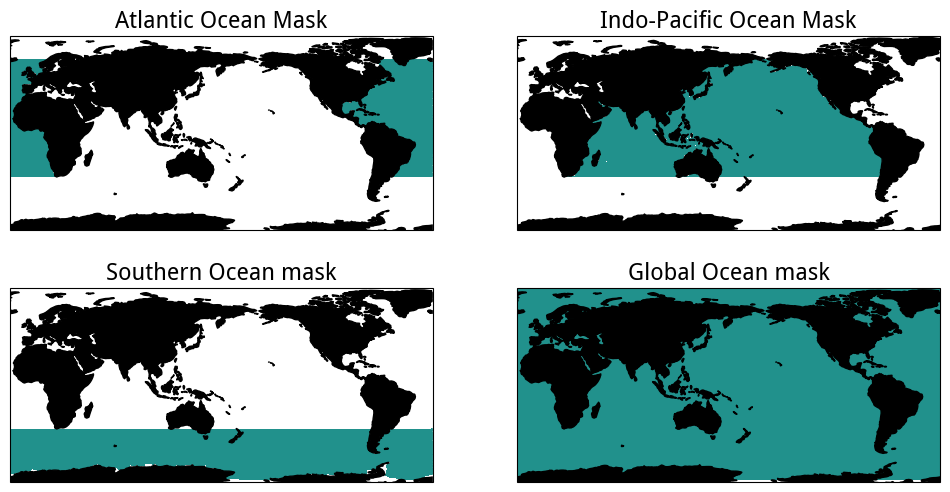

In [59]:
fig, axarr = plt.subplots(2, 2, figsize=(12, 6), subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=160)))

axlist = np.ravel(axarr)

xr.where(atlantic_sector_mask == 0, np.nan, 1).plot(ax=axlist[0], add_colorbar=False, transform=ccrs.PlateCarree())
axlist[0].set_ylim([-80, 85])
axlist[0].set_title('Atlantic Ocean Mask')
axlist[0].add_feature(cfeature.LAND, color='k', zorder=1)

xr.where(indo_pacific_sector_mask == 0, np.nan, 1).plot(ax=axlist[1], add_colorbar=False, transform=ccrs.PlateCarree())
axlist[1].set_ylim([-80, 85])
axlist[1].set_title('Indo-Pacific Ocean Mask');
axlist[1].add_feature(cfeature.LAND, color='k', zorder=1)

xr.where(southern_ocean_sector_mask == 0, np.nan, 1).plot(ax=axlist[2], add_colorbar=False, transform=ccrs.PlateCarree())
axlist[2].set_ylim([-80, 85])
axlist[2].set_title('Southern Ocean mask')
axlist[2].add_feature(cfeature.LAND, color='k', zorder=1)


xr.where(global_sector_mask == 0, np.nan, 1).plot(ax=axlist[3], add_colorbar=False, transform=ccrs.PlateCarree())
axlist[3].set_ylim([-80, 85])
axlist[3].set_title('Global Ocean mask')
axlist[3].add_feature(cfeature.LAND, color='k', zorder=1)

In [69]:
def compute_oht_basin(ds, basin_mask, time_slice=None, time_slice_stable=None, varname='temp_yflux_adv', chunks=None):
    """
    Compute total, overturning, and gyre OHT in a given ocean basin.
    
    Parameters
    ----------
    filelist : list of str
        List of NetCDF file paths containing the variable `varname`.
    basin_mask : xarray.DataArray (bool)
        Mask of the basin (same horizontal dims as the data: st_ocean, yt_ocean, xt_ocean or yt/xt only).
    time_slice : slice or str, optional
        Time slice to average, e.g., slice('1850','1900')
    varname : str
        Name of the variable to read (default: 'temp_yflux_adv')
    chunks : dict
        Dask chunking for efficient computation (optional)
    
    Returns
    -------
    dict with xarray.DataArrays:
        {
            'Q_total': total OHT (time, yt_ocean),
            'Q_overturning': overturning OHT (time, yt_ocean),
            'Q_gyre': gyre OHT (time, yt_ocean)
        }
    """
    # Open all files lazily
    flux = ds[varname].chunk(chunks)   # dims: time, st_ocean, yt_ocean, xt_ocean
    
    # Apply basin mask (broadcast if needed)
    flux_masked = flux.where(basin_mask)
    
    # --- Overturning (zonal-mean) ---
    # flux_zm = flux_masked.mean('xt_ocean')             # dims: time, st_ocean, yt_ocean
    # Q_overturning = flux_zm.sum('st_ocean')            # sum over depth -> dims: time, yt_ocean
    
    # --- Total OHT (full integral) ---
    Q_total = flux_masked.sum(['st_ocean', 'xt_ocean'])  # dims: time, yt_ocean
    
    # --- Gyre = Total - Overturning ---
    # Q_gyre = Q_total - Q_overturning
    
    # --- Time slice / averaging ---
    if time_slice is not None:
        Q_total = Q_total.sel(time=time_slice).mean('time')
        # Q_overturning = Q_overturning.sel(time=time_slice).mean('time')
        # Q_gyre = Q_gyre.sel(time=time_slice).mean('time')
    elif time_slice_stable is not None:
        Q_total = Q_total.isel(time=time_slice_stable).mean('time')
    

    # Compute (load into memory)
    with ProgressBar():
        Q_total = Q_total.compute()
        # Q_overturning = Q_overturning.compute()
        # Q_gyre = Q_gyre.compute()
    
    # return {
    #     'Q_total': Q_total,
    #     # 'Q_overturning': Q_overturning,
    #     # 'Q_gyre': Q_gyre
    # }
    return Q_total

In [38]:
oht_hist_atlantic = compute_oht_basin(hist_ds, basin_mask=atlantic_sector_mask, time_slice=slice('1850', '1900'))
oht_hist_indo_pacific = compute_oht_basin(hist_ds, basin_mask=indo_pacific_sector_mask, time_slice=slice('1850', '1900'))
oht_hist_global = compute_oht_basin(hist_ds, basin_mask=global_sector_mask, time_slice=slice('1850', '1900'))

[########################################] | 100% Completed | 151.58 s
[########################################] | 100% Completed | 93.42 s
[########################################] | 100% Completed | 93.49 s


In [39]:
oht_hist_atlantic.to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/oht_hist_atlantic.nc')
oht_hist_indo_pacific.to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/oht_hist_indo_pacific.nc')
oht_hist_global.to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/oht_hist_global.nc')

In [40]:
oht_ssp5_atlantic = compute_oht_basin(ssp5_ds, basin_mask=atlantic_sector_mask)
oht_ssp5_indo_pacific = compute_oht_basin(ssp5_ds, basin_mask=indo_pacific_sector_mask)
oht_ssp5_global = compute_oht_basin(ssp5_ds, basin_mask=global_sector_mask)

[########################################] | 100% Completed | 365.07 s
[########################################] | 100% Completed | 290.26 s
[########################################] | 100% Completed | 222.71 s


In [43]:
oht_ssp5_atlantic.to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/oht_ssp5_atlantic.nc')
oht_ssp5_indo_pacific.to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/oht_ssp5_indo_pacific.nc')
oht_ssp5_global.to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/oht_ssp5_global.nc')

In [ ]:
oht_stable_2060_atlantic = compute_oht_basin(stable_2060, basin_mask=atlantic_sector_mask, time_slice_stable=slice(100, -1))
oht_stable_2060_indo_pacific = compute_oht_basin(stable_2060, basin_mask=indo_pacific_sector_mask, time_slice_stable=slice(100, -1))
oht_stable_2060_global = compute_oht_basin(stable_2060, basin_mask=global_sector_mask, time_slice_stable=slice(100, -1))

[#######                                 ] | 17% Completed | 14m 22ss

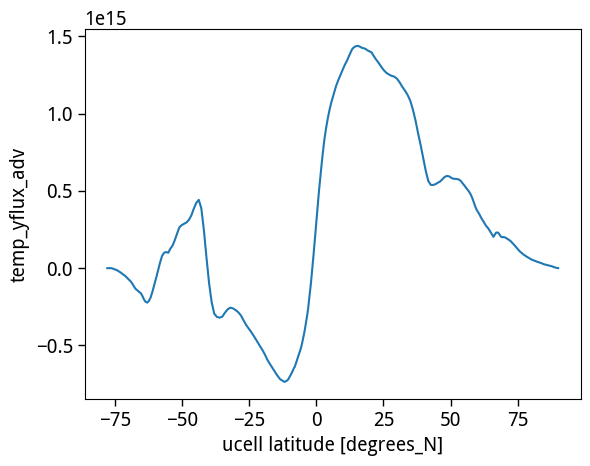

In [66]:
stable_2060.temp_yflux_adv.isel(time = slice(0, 50)).mean('time').sum(['st_ocean', 'xt_ocean']).plot()

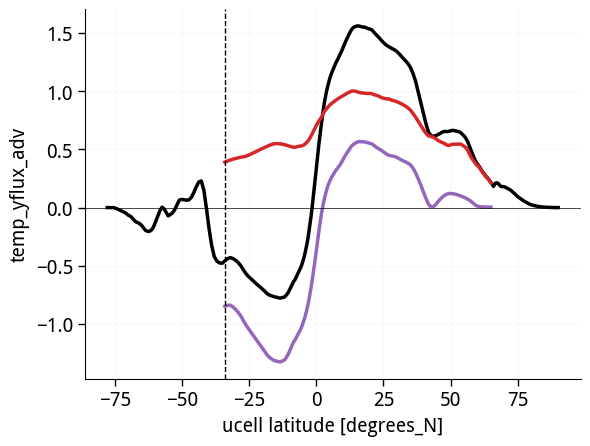

In [44]:
(oht_hist_global/1e15).plot(color='k', lw=2.5)
(oht_hist_atlantic/1e15).plot(color='tab:red', lw=2.5)
(oht_hist_indo_pacific/1e15).plot(color='tab:purple', lw=2.5)
# (southern_ocean_oht_pi/1e15).plot(color='tab:blue')
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(-34, lw=1.0, color='k', ls='--')
plot_decorator()

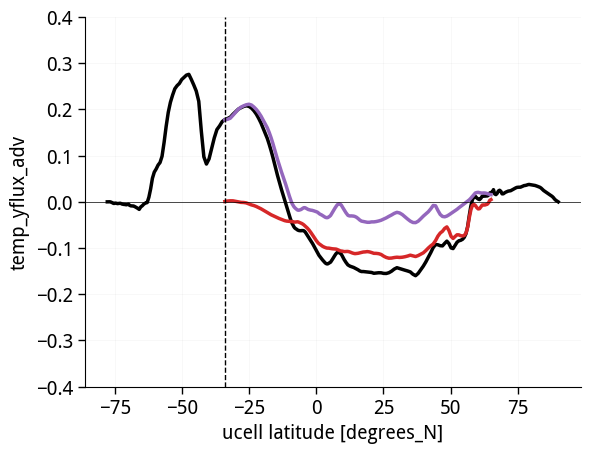

In [48]:
((oht_ssp5_global.sel(time = slice('2045', '2075')).mean('time') - oht_hist_global)/1e15).plot(color='k', lw=2.5)
((oht_ssp5_atlantic.sel(time = slice('2045', '2075')).mean('time') - oht_hist_atlantic)/1e15).plot(color='tab:red', lw=2.5)
((oht_ssp5_indo_pacific.sel(time = slice('2045', '2075')).mean('time') - oht_hist_indo_pacific)/1e15).plot(color='tab:purple', lw=2.5)
plt.axhline(0.0, lw=0.5, color='k')
plt.ylim(-0.4, 0.4)
plt.axvline(-34, lw=1.0, color='k', ls='--')
plot_decorator()

In [ ]:
((global_ocean_oht_stable2030 - global_ocean_oht_ssp5.sel(time = slice('2015', '2045')).mean('time'))/1e15).plot(color='k', lw=2.5)
((atlantic_oht_stable2030 - atlantic_oht_ssp5.sel(time = slice('2015', '2045')).mean('time'))/1e15).plot(color='tab:red', lw=2.5)
((indo_pacific_oht_stable2030 - indo_pacific_oht_ssp5.sel(time = slice('2015', '2045')).mean('time'))/1e15).plot(color='tab:purple', lw=2.5)
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(-34, lw=1.0, color='k', ls='--')
plt.ylim(-0.4, 0.4)
plot_decorator()